# Mel VAE inference: original vs. reconstruction

Test plan step 2 of `NOTES.md`: a recording goes through the mel front-end, the VAE encoder and decoder, and the VocBulwark vocoder. The notebook shows

1. the original mel and the VAE reconstruction side by side,
2. the original audio, its copy-synthesis (ground-truth mel through the vocoder, the quality ceiling) and the VAE reconstruction through the vocoder,
3. the latent `z` the energy model will later work on.

Run from the repo root with `uv run jupyter lab notebooks/vae_inference.ipynb` (the kernel must be the project's `.venv`).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # weight_norm deprecation inside the vocoder's remote code

from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Audio, display
from omegaconf import OmegaConf

import rootutils

ROOT = rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True, cwd=True)

from test_tts.audio.mel import WhisperMel, load_wav
from test_tts.audio.vocoder import VocBulwark
from test_tts.data.filelist import parse_filelist
from test_tts.training.utils import load_checkpoint, model_from_checkpoint, resolve_device

print("project root:", ROOT)

project root: /Users/felix/PhD/02_Edu/Test-TTS


## Load the VAE and the vocoder

`best.pt` holds the EMA weights with the lowest validation L1 and the mel statistics the model was trained with. Pick the newest run by default or set `CKPT` explicitly.

In [2]:
runs = sorted(ROOT.glob("logs/train_vae/be_vae/runs/*/checkpoints/best.pt"))
assert runs, "no trained VAE found under logs/train_vae/be_vae"
CKPT = runs[-1]
DEVICE = resolve_device("auto")

ckpt = load_checkpoint(CKPT)
cfg = OmegaConf.create(ckpt["cfg"])
vae = model_from_checkpoint(ckpt, DEVICE, use_ema=True)
MEAN, STD = float(ckpt["mel_stats"]["mean"]), float(ckpt["mel_stats"]["std"])

mel_fn = WhisperMel()  # the vocoder's own 96-mel Whisper front-end, reimplemented in torch
vocoder = VocBulwark.load(ROOT / "data/be_speaker_embedding.pt", device=str(DEVICE))
SR = vocoder.sample_rate

print(f"checkpoint : {CKPT.relative_to(ROOT)}  (step {ckpt['step']}, val/recon {ckpt['best_val_recon']:.4f})")
print(f"device     : {DEVICE}")
print(f"latent     : {vae.latent_dim} channels, compression {vae.compression}, "
      f"latent stats fitted: {bool(vae.latent_stats_fitted)}")

checkpoint : logs/train_vae/be_vae/runs/2026-10-08_14-05-16/checkpoints/best.pt  (step 60000, val/recon 0.0875)
device     : mps
latent     : 32 channels, compression 4, latent stats fitted: True


## Pick an utterance

Validation utterances were never seen in training. Change `INDEX`, or point `WAV` at any 24 kHz-or-other wav.

In [3]:
val = parse_filelist(cfg.data.valid_filelist, cfg.data.root)
INDEX = 0
WAV = val[INDEX].path
TEXT = val[INDEX].text

wav, _ = load_wav(WAV, SR)                     # mono float32 at 24 kHz
print(f"{WAV.name}: {len(wav) / SR:.2f} s")
print(TEXT)
display(Audio(wav.numpy(), rate=SR))

ch_be_0150.wav: 4.87 s
Dies Freibad ist die einzige zugelassene Badestelle im Obersee.


## Mel → VAE → mel

The mel is normalised with the corpus statistics before entering the VAE and denormalised afterwards. `sample=False` uses the posterior mean; set it to `True` to see how much a sampled `z` changes the output (it should be very little).

In [4]:
with torch.no_grad():
    mel = mel_fn(wav)                                      # (96, T) in the vocoder's feature space
    x = ((mel - MEAN) / STD)[None].to(DEVICE)              # (1, 96, T) normalised
    n = x.shape[-1]
    x = torch.nn.functional.pad(x, (0, (-n) % vae.compression))
    lengths = torch.tensor([n], device=DEVICE)
    out = vae(x, lengths, sample=False)
    mel_hat = out["mel_hat"][0, :, :n].cpu() * STD + MEAN  # back to the vocoder's space
    z = vae.normalize_latent(out["mu"])[0, :, : vae.latent_lengths(lengths)[0]].cpu()

err_db = (mel_hat - mel).abs().mean().item() * 40        # 1 Whisper-mel unit = 4 log10 = 40 dB
print(f"mel frames: {n}   latent: {tuple(z.shape)}   L1 (normalised): {out['recon']:.4f}   mean abs error: {err_db:.2f} dB")

mel frames: 456   latent: (32, 114)   L1 (normalised): 0.0701   mean abs error: 1.29 dB


## Original vs. reconstructed mel

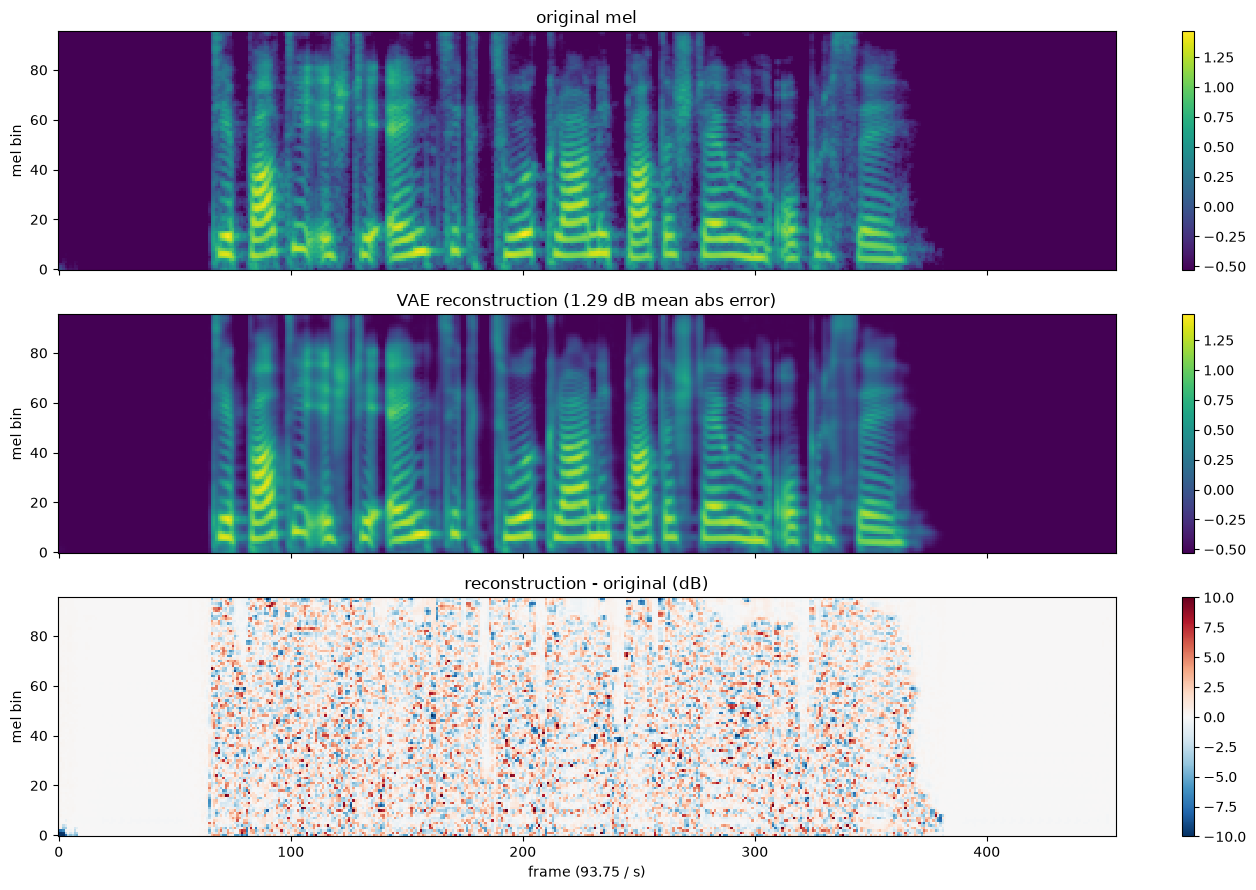

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
vmin, vmax = mel.min().item(), mel.max().item()
for ax, m, title in zip(axes, [mel, mel_hat], ["original mel", f"VAE reconstruction ({err_db:.2f} dB mean abs error)"]):
    im = ax.imshow(m.numpy(), aspect="auto", origin="lower", interpolation="none", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_ylabel("mel bin")
    fig.colorbar(im, ax=ax)
diff = (mel_hat - mel).numpy() * 40
im = axes[2].imshow(diff, aspect="auto", origin="lower", interpolation="none", cmap="RdBu_r", vmin=-10, vmax=10)
axes[2].set_title("reconstruction - original (dB)"); axes[2].set_xlabel("frame (93.75 / s)"); axes[2].set_ylabel("mel bin")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()

## Original vs. generated audio

`copysynth` is the ground-truth mel through the vocoder, so it is the best the reconstruction could possibly sound; judge the VAE against it rather than against the recording.

In [6]:
with torch.no_grad():
    copysynth = vocoder(mel)[0].cpu().numpy()
    recon = vocoder(mel_hat)[0].cpu().numpy()

for name, audio in [("original recording", wav.numpy()), ("copy-synthesis (mel -> vocoder)", copysynth), ("VAE reconstruction (mel -> VAE -> vocoder)", recon)]:
    print(name)
    display(Audio(audio, rate=SR))

original recording


copy-synthesis (mel -> vocoder)


VAE reconstruction (mel -> VAE -> vocoder)


## The latent

This is what the energy model sees: `(32, T/4)`, normalised per channel to roughly unit variance using the statistics fitted by `tts-vae-latent-stats`.

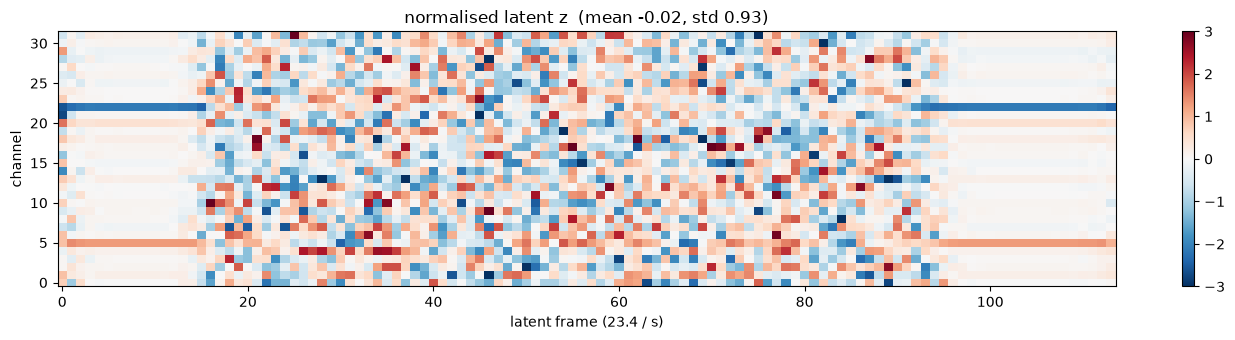

In [7]:
fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(z.numpy(), aspect="auto", origin="lower", interpolation="none", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_title(f"normalised latent z  (mean {z.mean():.2f}, std {z.std():.2f})"); ax.set_xlabel("latent frame (23.4 / s)"); ax.set_ylabel("channel")
fig.colorbar(im, ax=ax)
plt.tight_layout()

## Optional: save the wavs

Writes the three wavs next to the notebook under `synth_output/notebook/`; `tts-vocode` does the same from the command line.

In [8]:
import soundfile as sf

out_dir = ROOT / "synth_output" / "notebook"
out_dir.mkdir(parents=True, exist_ok=True)
for name, audio in [("original", wav.numpy()), ("copysynth", copysynth), ("recon", recon)]:
    sf.write(out_dir / f"{WAV.stem}_{name}.wav", audio, SR)
print("written to", out_dir.relative_to(ROOT))

written to synth_output/notebook
